In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from src.mslandcover.models import HRNetSegmentationModel, get_cls_net
from src.mslandcover.config import HRNET_W18_CONFIG
from src.mslandcover.utils import load_pth

In [ ]:
model = HRNetSegmentationModel(
    config=HRNET_W18_CONFIG,
    img_decoder_head=True,
    use_simple_decoder=False,
    use_se_decoder=True,
    unet_like_decoder=True,
    
)
model.load_encoder_weights(load_pth('./weights/hrnet_w18/new/dae_hsv_simclr.pth', map_location='cpu'))
model.eval()

HRNetSegmentationModel(
  (encoder): HighResolutionNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, 

In [38]:
import h5py

with h5py.File('/scratch/dhester/mslc/pretrain.hdf5', 'r') as f:
    group = f['pretrain']
    keys = list(group.keys())
    sample = group[keys[1]][()]

sample_tensor = torch.from_numpy(sample)

In [39]:

y_pred, _ = model(sample_tensor.unsqueeze(0))
y_pred_numpy = y_pred.detach().numpy()

(3, 256, 256)
(3, 256, 256)
(1, 3, 256, 256)


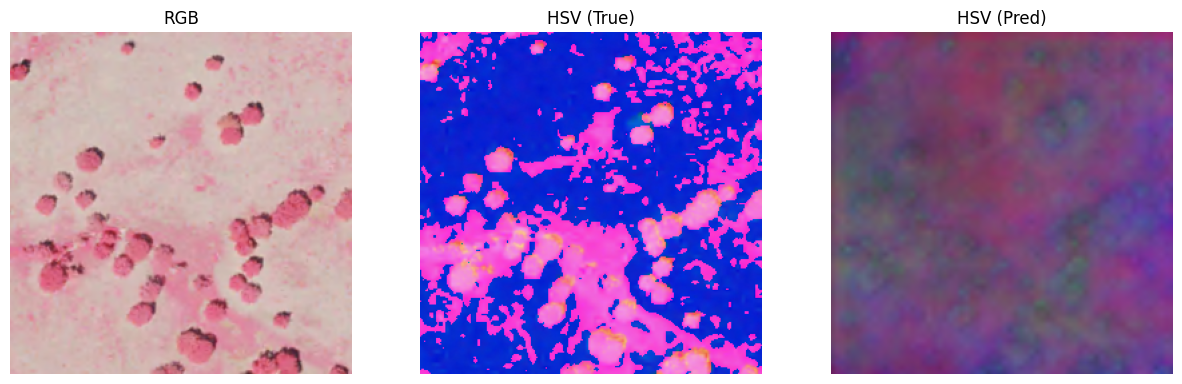

In [40]:
from src.mslandcover.data.transforms import rgb_to_hsv
import matplotlib.pyplot as plt

y_true = rgb_to_hsv(sample_tensor)
y_true_numpy = y_true.numpy().squeeze()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name, img in zip(
    axes,
    ['RGB', 'HSV (True)', 'HSV (Pred)'],
    [sample, y_true_numpy, y_pred_numpy]
):
    print(img.shape)
    ax.imshow(img.squeeze().transpose(1, 2, 0))
    ax.set_title(name)
    ax.axis('off')

plt.show()

In [63]:
model = HRNetSegmentationModel(
    config=HRNET_W18_CONFIG,
    img_decoder_head=True,
    use_simple_decoder=True,
    aux_simclr_head=False,
    num_classes=7
)
model.eval()
state_dict = torch.load('./weights/hrnet_w18/new/dae_hsv_simclr.pth', map_location='cpu')
for key in list(state_dict.keys()):
    if not key.startswith('encoder'):
        state_dict.pop(key)
    else:
        state_dict[key.replace('encoder.', '')] = state_dict.pop(key)
# print(state_dict)
model.load_encoder_weights(state_dict)

trainable_params = 0
unfrozen_stages = ['encoder.stage4.2', 'decoder.classifier']
for param in model.named_parameters():
    for stage in unfrozen_stages:
        if stage in param[0]:
            param[1].requires_grad = True
            trainable_params += param[1].numel()
            break
            
print(trainable_params)

2238109


/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_40388/2153697583.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('./weights/hrnet_w18/

In [77]:
trainable_stages = [
    'decoder',
    'encoder.stage4.2',
    'encoder.stage4.1',
    'encoder.stage4.0',
    'encoder.transition3',
    'encoder.stage3.3',
    'encoder.stage3.2',
    'encoder.stage3.1',
    'encoder.stage3.0',
    'encoder.transition2',
    'encoder.stage2.0',
    'encoder.transition1',
    'encoder.layer1',
    'encoder.' # full encoder
]

trainable_params_dict = {}
for i in range(len(trainable_stages)):
    trainable_params = 0
    for param in model.named_parameters():
        for stage in trainable_stages[:i]:
            if stage in param[0]:
                trainable_params += param[1].numel()
    trainable_params_dict[i] = trainable_params

In [78]:
trainable_params_dict

{0: 0,
 1: 1897,
 2: 2238109,
 3: 4474321,
 4: 6710533,
 5: 6804133,
 6: 7344853,
 7: 7885573,
 8: 8426293,
 9: 8967013,
 10: 8990485,
 11: 9114577,
 12: 9239101,
 13: 9525309}

           loss  accuracy  f1_score  precision_score  recall_score  \
0  24337.846875  0.732417  0.689411         0.702244      0.732417   

   macro_f1_score  macro_precision_score  macro_recall_score  kappa_score  
0        0.247599               0.343566            0.268387     0.537696  
           loss  accuracy  f1_score  precision_score  recall_score  \
0  17757.657031  0.752644  0.755848         0.798648      0.752644   

   macro_f1_score  macro_precision_score  macro_recall_score  kappa_score  
0        0.427723               0.452578            0.477775     0.605625  
           loss  accuracy  f1_score  precision_score  recall_score  \
0  17950.376897  0.749275  0.752775         0.786309      0.749275   

   macro_f1_score  macro_precision_score  macro_recall_score  kappa_score  
0        0.423428               0.442081             0.46905     0.599284  
           loss  accuracy  f1_score  precision_score  recall_score  \
0  18582.734487  0.741139  0.742143         0.77864

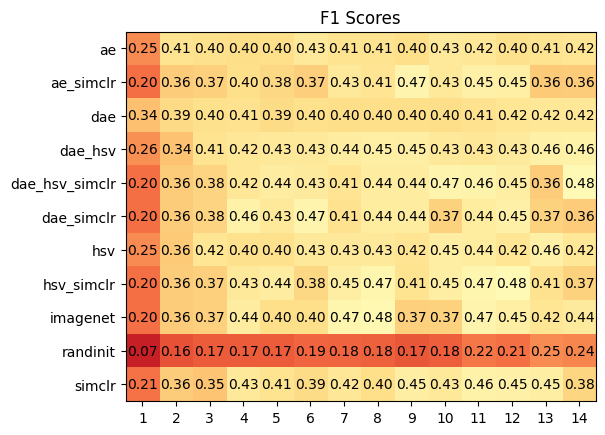

In [10]:
import pandas as pd
from glob import glob
import os

test_metrics_csv_paths = glob('./logs/finetune_20250108/*/*/test_metrics.csv')
# print(test_metrics_csv_paths)

dfs = []
for csv_path in test_metrics_csv_paths:
    parent_dir = os.path.dirname(csv_path)
    num_layers_trained = int(os.path.basename(parent_dir))
    weights_used = os.path.basename(os.path.dirname(parent_dir))
    df = pd.read_csv(csv_path)
    print(df)
    df['num_layers_trained'] = num_layers_trained
    df['weights_used'] = weights_used
    dfs.append(df)

test_metrics_df = pd.concat(dfs)
test_metrics_df = test_metrics_df.sort_values(['num_layers_trained', 'weights_used'])
# test_metrics_df.set_index(['num_layers_trained', 'weights_used'])
f1_scores = test_metrics_df[['macro_f1_score', 'num_layers_trained', 'weights_used']]

# plot as matrix with num_layers_trained as x-axis and weights_used as y-axis
import matplotlib.pyplot as plt

f1_scores_pivot = f1_scores.pivot(index='weights_used', columns='num_layers_trained', values='macro_f1_score')
# f1_scores_pivot = f1_scores_pivot / f1_scores_pivot.max().max()

fig, ax = plt.subplots()
ax.set_title('F1 Scores')
print(f1_scores_pivot)
ax.imshow(f1_scores_pivot, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(len(f1_scores_pivot.columns)))
ax.set_xticklabels(f1_scores_pivot.columns)
ax.set_yticks(range(len(f1_scores_pivot.index)))
ax.set_yticklabels(f1_scores_pivot.index)

# include values in matrix
for i in range(len(f1_scores_pivot.index)):
    for j in range(len(f1_scores_pivot.columns)):
        ax.text(j, i, f'{f1_scores_pivot.iloc[i, j]:.2f}', ha='center', va='center', color='black')



In [58]:
from torchvision.models import resnet152, ResNet152_Weights
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial

model = resnet152(ResNet152_Weights.DEFAULT)

# remove adaptive avg pooling and fc layer without using sequential
model.avgpool = nn.Identity()
model.fc = nn.Identity()

# X = torch.randn(1, 3, 96, 96)
# for module in model.children():
    # X = module(X)
    # if module is layer1 or layer2 or layer3 or layer4
    # then print the shape of X
    # if isinstance(module, nn.Sequential):
        # print(X.shape)
    # print(X.shape)

def modified_forward(self, x):
    x_list =[]
    # x_dim = x.shape[2:]
    for module in self.children():
        x = module(x)
        if isinstance(module, nn.Sequential):
            x_list.append(x)
        
    # out_x_list = []
    for i, x in enumerate(x_list):
        if i == 0:
            x_dim = x.shape[2:]
        x_list[i] = F.interpolate(x, size=x_dim, mode='bilinear', align_corners=True)
        print(x_list[i].shape)

    return torch.concat(x_list, dim=1)

model.forward = partial(modified_forward, model)

X = torch.randn(1, 3, 48, 48)
y = model(X)
print(y.shape)

c:\Users\dh2306\projects\ms-land-cover\.env\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


torch.Size([1, 256, 12, 12])
torch.Size([1, 512, 12, 12])
torch.Size([1, 1024, 12, 12])
torch.Size([1, 2048, 12, 12])
torch.Size([1, 3840, 12, 12])


In [ ]:
from src.mslandcover.models import ResNetAutoencoder
from src.mslandcover.utils import load_pth

model = ResNetAutoencoder(
    use_simple_decoder=True,
    unet_like_decoder=True,
    num_classes=3,
    aux_simclr_head=False,
    pretrained=True
)

X = torch.randn(1, 3, 256, 256)
y_1 = model(X)
model.load_encoder_weights(load_pth('./weights/resnet_152_20250113/dae_hsv_simclr.pth'))
y_2 = model(X)
print(torch.allclose(y_1, y_2))

False


In [2]:
import torch
from src.mslandcover.models import UNet, UNetUpBlock
from torchvision.models import resnet152

# model = resnet152()
unet = UNet()

X = torch.randn(1, 3, 256, 256)
for block in unet.encoder_blocks:
    X = block(X)
    print(X.shape)

total_params = sum(p.numel() for p in unet.parameters())
encoder_params = sum(p.numel() for p in unet.encoder.parameters())
decoder_params = sum(p.numel() for decoder_block in unet.decoder_blocks for p in decoder_block.parameters())
classifier_params = sum(p.numel() for p in unet.classifier.parameters())
print(total_params, encoder_params, decoder_params, classifier_params)

y = unet(X)
print(y.shape)

torch.Size([1, 64, 128, 128])
torch.Size([1, 256, 64, 64])
torch.Size([1, 512, 32, 32])
torch.Size([1, 1024, 16, 16])
torch.Size([1, 2048, 8, 8])
108328136 58143808 50183808 520


In [26]:
from timm.models.convnext import convnextv2_small
# from torchvision.models import s
import torch

model = convnextv2_small()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total params: {total_params}, Trainable params: {trainable_params}')

X = torch.randn(1, 3, 256, 256)

for stage in model.stages:
    X = stage(X)
    print(X.shape)

Total params: 50318440, Trainable params: 50318440


RuntimeError: Given groups=96, weight of size [96, 1, 7, 7], expected input[1, 3, 256, 256] to have 96 channels, but got 3 channels instead

In [32]:
import torch
from torch import nn
from torch.nn import functional as F
# class DeepLabV3(_SimpleSegmentationModel):
    # """
    # Implements DeepLabV3 model from
    # `"Rethinking Atrous Convolution for Semantic Image Segmentation"
    # <https://arxiv.org/abs/1706.05587>`_.

    # Arguments:
    #     backbone (nn.Module): the network used to compute the features for the model.
    #         The backbone should return an OrderedDict[Tensor], with the key being
    #         "out" for the last feature map used, and "aux" if an auxiliary classifier
    #         is used.
    #     classifier (nn.Module): module that takes the "out" element returned from
    #         the backbone and returns a dense prediction.
    #     aux_classifier (nn.Module, optional): auxiliary classifier used during training
    # """
    # pass

class DeepLabHeadV3Plus(nn.Module):
    def __init__(self, in_channels, low_level_channels, num_classes, aspp_dilate=[12, 24, 36]):
        super(DeepLabHeadV3Plus, self).__init__()
        self.project = nn.Sequential( 
            nn.Conv2d(low_level_channels, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )

        self.aspp = ASPP(in_channels, aspp_dilate)

        self.classifier = nn.Sequential(
            nn.Conv2d(304, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1)
        )
        self._init_weight()

    def forward(self, feature):
        low_level_feature = self.project( feature['low_level'] )
        output_feature = self.aspp(feature['out'])
        output_feature = F.interpolate(output_feature, size=low_level_feature.shape[2:], mode='bilinear', align_corners=False)
        return self.classifier( torch.cat( [ low_level_feature, output_feature ], dim=1 ) )
    
    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

class DeepLabHead(nn.Module):
    def __init__(self, in_channels, num_classes, aspp_dilate=[12, 24, 36]):
        super(DeepLabHead, self).__init__()

        self.classifier = nn.Sequential(
            ASPP(in_channels, aspp_dilate),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1)
        )
        self._init_weight()

    def forward(self, feature):
        return self.classifier( feature['out'] )

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

class AtrousSeparableConvolution(nn.Module):
    """ Atrous Separable Convolution
    """
    def __init__(self, in_channels, out_channels, kernel_size,
                            stride=1, padding=0, dilation=1, bias=True):
        super(AtrousSeparableConvolution, self).__init__()
        self.body = nn.Sequential(
            # Separable Conv
            nn.Conv2d( in_channels, in_channels, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, bias=bias, groups=in_channels ),
            # PointWise Conv
            nn.Conv2d( in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=bias),
        )
        
        self._init_weight()

    def forward(self, x):
        return self.body(x)

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

class ASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        modules = [
            nn.Conv2d(in_channels, out_channels, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        super(ASPPConv, self).__init__(*modules)

class ASPPPooling(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super(ASPPPooling, self).__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))

    def forward(self, x):
        size = x.shape[-2:]
        x = super(ASPPPooling, self).forward(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)

class ASPP(nn.Module):
    def __init__(self, in_channels, atrous_rates):
        super(ASPP, self).__init__()
        out_channels = 256
        modules = []
        modules.append(nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)))

        rate1, rate2, rate3 = tuple(atrous_rates)
        modules.append(ASPPConv(in_channels, out_channels, rate1))
        modules.append(ASPPConv(in_channels, out_channels, rate2))
        modules.append(ASPPConv(in_channels, out_channels, rate3))
        modules.append(ASPPPooling(in_channels, out_channels))

        self.convs = nn.ModuleList(modules)

        self.project = nn.Sequential(
            nn.Conv2d(5 * out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),)

    def forward(self, x):
        res = []
        for conv in self.convs:
            res.append(conv(x))
        res = torch.cat(res, dim=1)
        return self.project(res)



def convert_to_separable_conv(module):
    new_module = module
    if isinstance(module, nn.Conv2d) and module.kernel_size[0]>1:
        new_module = AtrousSeparableConvolution(module.in_channels,
                                      module.out_channels, 
                                      module.kernel_size,
                                      module.stride,
                                      module.padding,
                                      module.dilation,
                                      module.bias)
    for name, child in module.named_children():
        new_module.add_module(name, convert_to_separable_conv(child))
    return new_module

In [35]:
for stage in model.stages:
    print(stage)

ConvNeXtStage(
  (downsample): Identity()
  (blocks): Sequential(
    (0): ConvNeXtBlock(
      (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
      (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
      (mlp): GlobalResponseNormMlp(
        (fc1): Linear(in_features=96, out_features=384, bias=True)
        (act): GELU()
        (drop1): Dropout(p=0.0, inplace=False)
        (grn): GlobalResponseNorm()
        (fc2): Linear(in_features=384, out_features=96, bias=True)
        (drop2): Dropout(p=0.0, inplace=False)
      )
      (shortcut): Identity()
      (drop_path): Identity()
    )
    (1): ConvNeXtBlock(
      (conv_dw): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
      (norm): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
      (mlp): GlobalResponseNormMlp(
        (fc1): Linear(in_features=96, out_features=384, bias=True)
        (act): GELU()
        (drop1): Dropout(p=0.0, inplace=Fals

In [6]:
import rasterio as rio
from glob import glob
from src.mslandcover.config import LEGEND_COLORS_RGBA
from tqdm import tqdm
import os

server_dir = '/home/dhester/server/guser/dh/MS_HiRes_LC_Prelim/001/lc_classes.tif'

# correct metadata for each lc_classes file
for file in tqdm(
    glob('/home/dhester/server/guser/dh/MS_HiRes_LC_Prelim/*/lc_classes.tif'),
    desc='Correcting metadata',
    unit='file'
):
    out_dir = file.replace('lc_classes.tif', 'lc_classes_corrected.tif')
    if os.path.exists(out_dir):
        continue
    
    try:
        with rio.open(file) as src:
            profile = src.profile
            data = src.read(1)
    except rio.RasterioIOError as e:
        # bad data file, best to just remove all files in the directory
        print(f'Bad data file: {file}')
        for f in glob(os.path.dirname(file) + '/*'):
            os.remove(f)
        continue

    profile.update(count=1, dtype='uint8', nodata=0)
    with rio.open(out_dir, 'w', **profile) as dst:
        dst.write(data, 1)
        dst.write_colormap(1, LEGEND_COLORS_RGBA)
# with rio.open(server_dir) as src:
#     print(src.profile)
#     print(src.read(2).shape)

Correcting metadata:  90%|█████████ | 55/61 [00:00<00:00, 469.77file/s]

Bad data file: /home/dhester/server/guser/dh/MS_HiRes_LC_Prelim/121/lc_classes.tif


Correcting metadata: 100%|██████████| 61/61 [02:16<00:00,  2.24s/file] 


In [38]:
import torch
import torch.nn as nn
from torchvision.models import resnet152
from torchvision.models.resnet import Bottleneck
from time import time

resnet_model = resnet152()

class ConvBlock(nn.Module):
    
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=bias)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

class CustomStem(nn.Module):
    
    def __init__(self, in_channels, out_channels, n_layers=3):
        super(CustomStem, self).__init__()
        self.conv_1x1 = ConvBlock(in_channels, out_channels, 1)
        
        self.conv_3x3_list = nn.ModuleList([])
        for i in range(n_layers):
            layer_in_channels = in_channels if i == 0 else out_channels
            self.conv_3x3_list.append(ConvBlock(layer_in_channels, out_channels, 3, padding=1))
    
    def forward(self, x):
        x_list = [self.conv_1x1(x)]
        for layer in self.conv_3x3_list:
            x = layer(x)
            for x_prev in x_list:
                x += x_prev
            x_list.append(x)
        
        return x

encoder_blocks = nn.ModuleList([
    nn.Sequential(
        CustomStem(3, 64, 3),
        resnet_model.layer1
    ),
    resnet_model.layer2,
    resnet_model.layer3,
    resnet_model.layer4,
])

print(f'Stem params: {sum(p.numel() for p in encoder_blocks[0].parameters())}')

X = torch.randn(1, 3, 256, 256)
device = 'mps'
encoder_blocks.to(device)
X = X.to(device)
for block in encoder_blocks:
    start_time = time()
    X = block(X)
    print(time() - start_time, X.shape)
    # print(X.shape)


Stem params: 76416
0.005239009857177734 torch.Size([1, 64, 256, 256])
0.3251500129699707 torch.Size([1, 256, 128, 128])
0.6421582698822021 torch.Size([1, 512, 64, 64])
0.12491679191589355 torch.Size([1, 1024, 32, 32])
0.0058689117431640625 torch.Size([1, 2048, 16, 16])


In [39]:


print(block(X, X, X)[0].shape)

torch.Size([10, 32, 512])


In [25]:
from torch.nn.functional import interpolate
from functools import partial
upsample_block = partial(interpolate, scale_factor=2, mode='bilinear', align_corners=False)
decoder_block = Bottleneck(1024, 512, 1)

In [34]:
print(f'Stem params: {sum(p.numel() for p in encoder_blocks[0].parameters())}')

Stem params: 76416


In [ ]:
class DenseBlock(nn.Module):
    
    def __init__(self, in_channels, out_channels, n_layers=3):
        super(DenseBlock, self).__init__()
        
        

In [42]:
device = 'mps'
encoder_blocks = nn.ModuleList([
    resnet_model.layer1,
    resnet_model.layer2,
    resnet_model.layer3,
    resnet_model.layer4,
]).to(device)

X = torch.randn(1, 64, 256, 256).to(device)

for block in encoder_blocks:
    start_time = time()
    X = block(X)
    print(time() - start_time, X.shape)

0.010397195816040039 torch.Size([1, 256, 256, 256])
1.976647138595581 torch.Size([1, 512, 128, 128])
0.27331018447875977 torch.Size([1, 1024, 64, 64])
0.011449098587036133 torch.Size([1, 2048, 32, 32])


In [ ]:
class DenseConvBlock(nn.Module):
    
    def __init__(self,
        in_channels: int,
        out_channels: int,
        n_layers: int=3,
    ):
        super(DenseConvBlock, self).__init__()
        self.conv_1x1 = ConvBlock(in_channels, out_channels, 1)
        self.conv_3x3_list = nn.ModuleList([])
        for i in range(n_layers):
            layer_in_channels = in_channels + i * out_channels
            self.conv_3x3_list.append(ConvBlock(layer_in_channels, out_channels, 3, padding=1))
        
    def forward(self, x):
        x_list = [self.conv_1x1(x)]
        for layer in self.conv_3x3_list:
            x = layer(torch.cat(x_list, dim=1))
            x_list.append(x)
        
        return x




In [ ]:
class AttentionGate(nn.Module):
    
    def __init__(self,
        F_g: int, # number of features from decoder (gating signal)
        F_l: int, # number of features from encoder (input feature maps)
        F_int: int, # number of features in intermediate layers
        downsampling_method: str='bilinear', # method to use for downsampling input feature maps to match the size of the gating signal
        upsampling_method: str='bilinear', # method to use for upsampling the attention map to match the size of the input feature maps
    ):
        """
        
        """
        
        super(AttentionGate, self).__init__()
        self.F_g = F_g
        self.F_l = F_l
        self.F_int = F_int
        self.downsampling_method = downsampling_method
        self.upsampling_method = upsampling_method
        
        self.W_g = ConvBlock(F_g, F_int, 1)
        self.W_x = ConvBlock(F_l, F_int, 1)
        self.psi = ConvBlock(F_int, 1, 1)
    
    def forward(self, g: torch.Tensor, x: torch.Tensor,) -> torch.Tensor:
        """Forward pass of the attention gate.

        Args:
            x (torch.Tensor): Feature map from the encoder
            g (torch.Tensor): Gating signal from the previous decoder block

        Returns:
            torch.Tensor: Gated feature map from encoder
        """
        
        x_downsampled = F.interpolate(x, size=g.shape[2:], mode=self.downsampling_method, align_corners=False)
        g_proj = self.W_g(g)
        x_proj = self.W_x(x_downsampled)
        
        psi = self.psi(F.relu(g_proj + x_proj))
        psi = torch.sigmoid(psi)
        alpha = F.interpolate(psi, size=x.shape[2:], mode=self.upsampling_method, align_corners=False)
        
        return x * alpha



def GatedUpsampleBlock(nn.Module):
    
    def __init__(self,
        enc_in_channels: int,
        dec_in_channels: int,
        out_channels: int,
        n_layers: int=3,
    ):
        super(GatedUpsampleBlock, self).__init__()
        
        self.attention_gate = AttentionGate(F_g=dec_in_channels, F_l=enc_in_channels, F_int=enc_in_channels // 2)
        
        self.conv_blocks = nn.ModuleList([])
        
    
    
    def forward(self, enc_x, dec_x):
        
        enc_x_gated = self.attention_gate(enc_x, dec_x)
        dec_x_upsampled = F.interpolate(dec_x, size=enc_x_gated.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([enc_x_gated, dec_x_upsampled], dim=1)
        
        
        
        
        
        

class ResAttentionUNet(nn.Module):
    
    def __init__(self,
        in_channels: int=3,
        out_classes: int=3,
        pretrained: bool=True,
    ):
        super(ResAttentionUNet, self).__init__()
        
        self.in_channels = in_channels
        self.out_classes = out_classes
        self.pretrained = pretrained
        
        self.encoder = resnet152(weights=ResNet152_Weights.DEFAULT if pretrained else None)
        
        self.stem = ConvBlock(in_channels, 64, 1)
        self.encoder_blocks = nn.ModuleList([
            self.encoder.layer1,
            self.encoder.layer2,
            self.encoder.layer3,
            self.encoder.layer4,
        ])


In [45]:
x = torch.randn(1, 64, 256, 256).to(device)
for block in encoder_blocks:
    start_time = time()
    x = block(x)
    print(time() - start_time, x.shape)
# print(x.shape)

0.006165981292724609 torch.Size([1, 256, 256, 256])
4.186462879180908 torch.Size([1, 512, 128, 128])
9.850300073623657 torch.Size([1, 1024, 64, 64])
3.2296042442321777 torch.Size([1, 2048, 32, 32])


In [40]:
import torch
import torch.nn as nn
from src.mslandcover.models import ResNetAutoencoder
from src.mslandcover.utils import load_pth
import rasterio as rio


resnet_ae = ResNetAutoencoder(
    use_simple_decoder=True,
    unet_like_decoder=True,
    num_classes=3,
    aux_simclr_head=False,
    pretrained=False
)
resnet_ae.load_state_dict(load_pth('./weights/resnet152/dae_l1loss.pth'))

<All keys matched successfully>

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


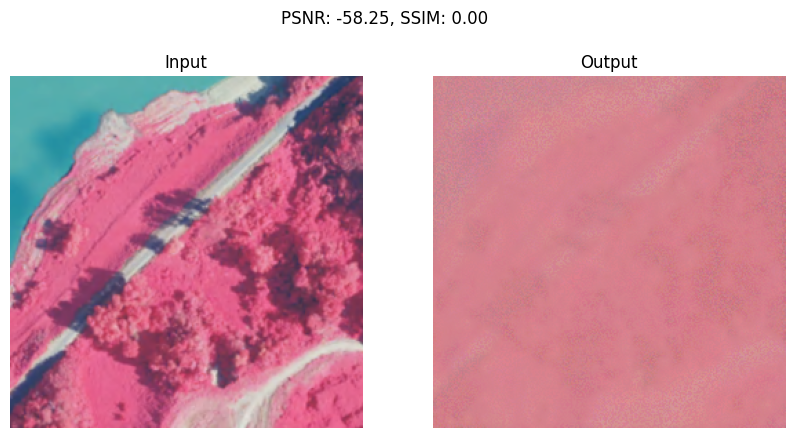

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


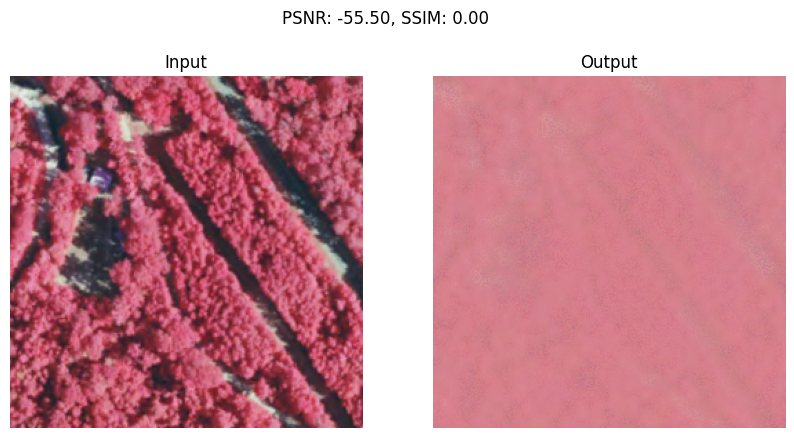

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


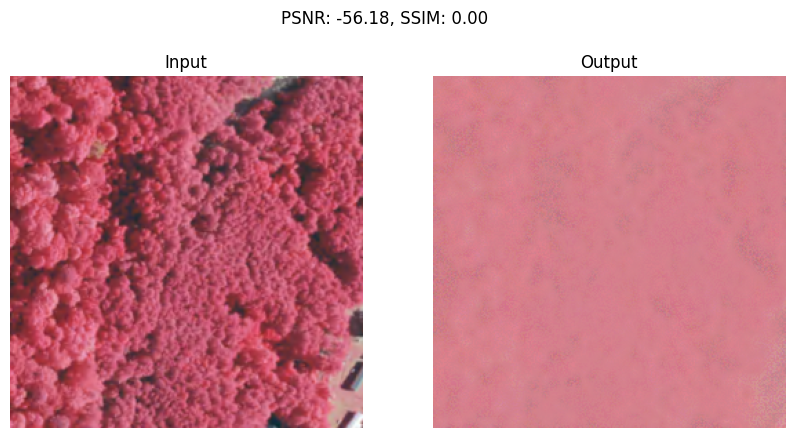

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


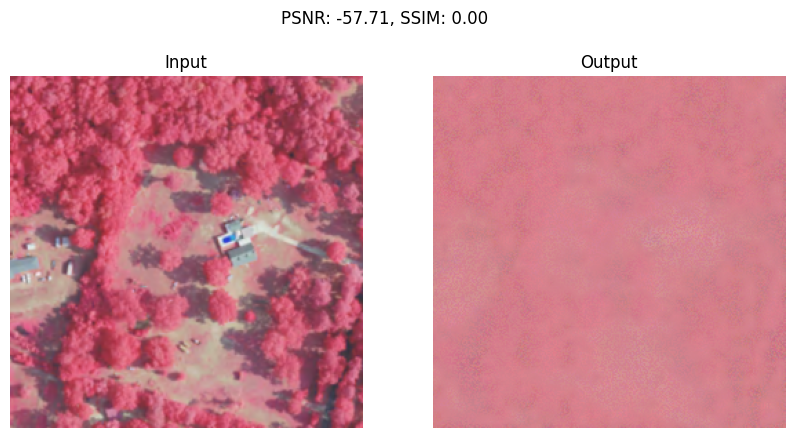

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


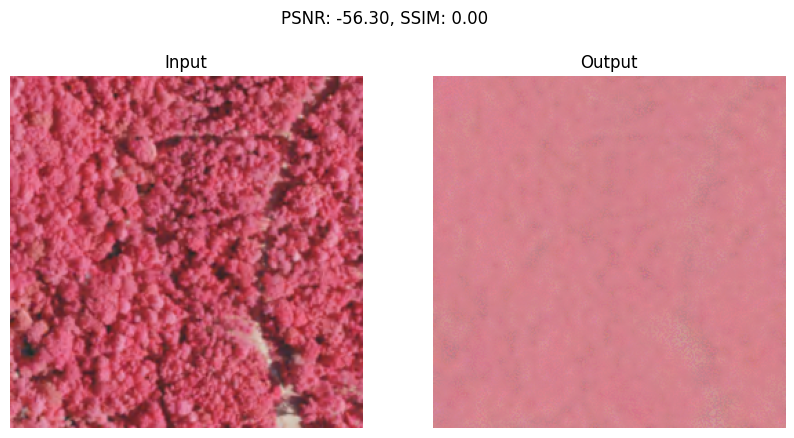

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


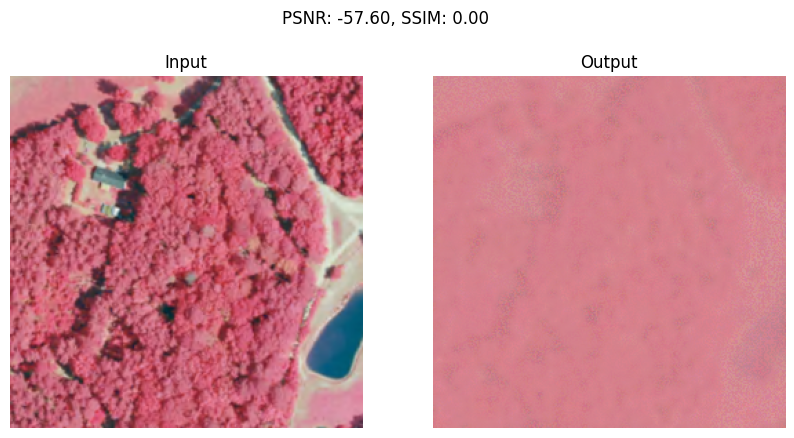

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


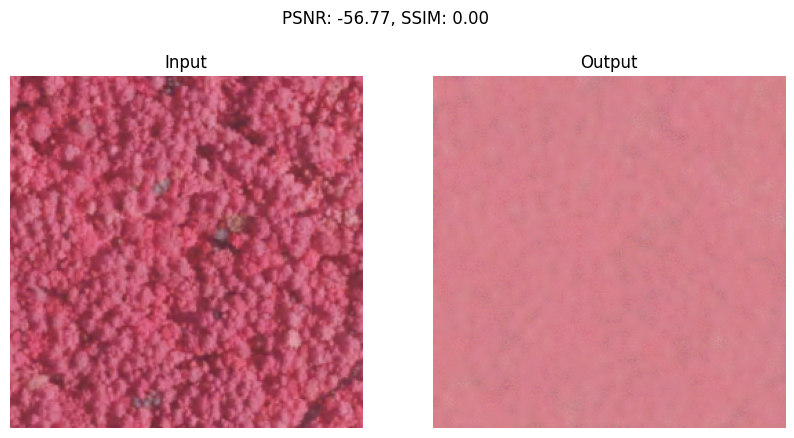

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


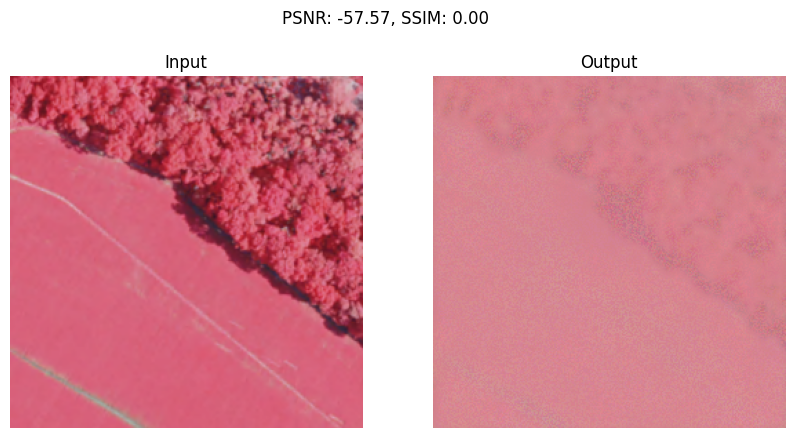

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


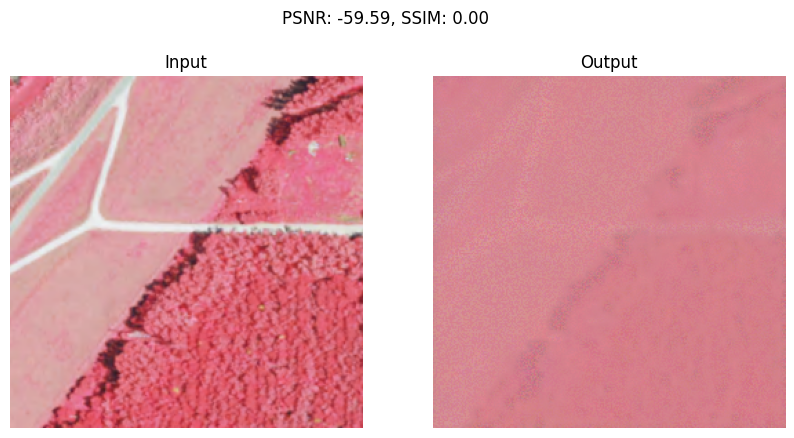

torch.Size([1, 3, 256, 256])
torch.Size([1, 256, 256, 3])
torch.Size([1, 3, 256, 256])


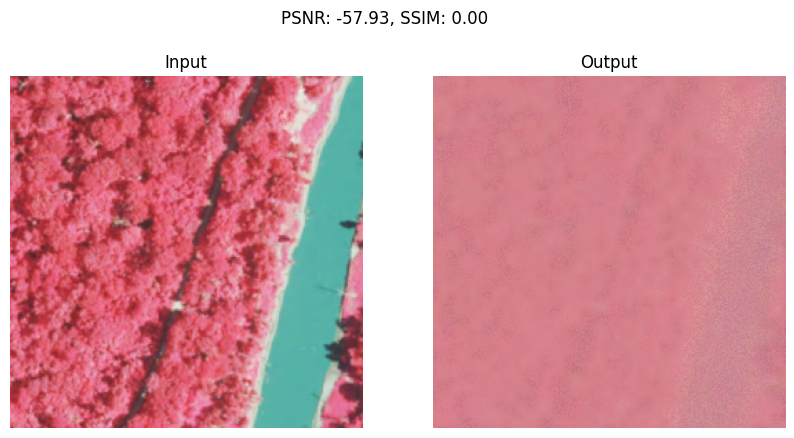

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from src.mslandcover.metrics import psnr, ssim

file_list = glob('./data/splits/test/input/*.tif')

for i in range(10):
    with rio.open(file_list[i]) as src:
        X = src.read()

    mean = load_pth('./weights/pretrain_mean.pth')
    std = load_pth('./weights/pretrain_std.pth')

    X = torch.from_numpy(X).unsqueeze(0)
    print(X.shape)
    X_norm = X.permute(0, 2, 3, 1)
    print(X_norm.shape)
    X_norm = (X_norm - mean) / std
    X_norm = X_norm.permute(0, 3, 1, 2)
    print(X_norm.shape)

    y_norm = resnet_ae(X_norm)
    psnr_val = psnr(X_norm, y_norm, reduction='sum')
    ssim_val = ssim(X_norm, y_norm, reduction='sum')
    y = y_norm.permute(0, 2, 3, 1)
    y = y * std + mean
    y = y.detach().squeeze().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(X.squeeze().numpy().transpose(1, 2, 0))
    axes[0].set_title('Input')
    axes[0].axis('off')
    axes[1].imshow(y)
    axes[1].set_title('Output')
    axes[1].axis('off')
    plt.suptitle(f'PSNR: {psnr_val:.2f}, SSIM: {ssim_val:.2f}')
    plt.show()
